# Packages

In [65]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
import shap
from xgboost import XGBClassifier
from catboost import CatBoostClassifier
from sklearn.svm import SVC
from tabulate import tabulate
from imblearn.under_sampling import RandomUnderSampler
from sklearn.ensemble import RandomForestClassifier
from sklearn.utils import resample
from sklearn.discriminant_analysis import StandardScaler
from sklearn.pipeline import make_pipeline, Pipeline
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score, StratifiedKFold
from sklearn.metrics import classification_report, accuracy_score, precision_score, recall_score, f1_score,roc_curve, auc, roc_auc_score, confusion_matrix, ConfusionMatrixDisplay
from sklearn.linear_model import LogisticRegression
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.preprocessing import OneHotEncoder, StandardScaler,LabelEncoder
from sklearn.compose import ColumnTransformer


# Data

In [66]:
data_cleaned = pd.read_csv(r'C:\Users\natal\Github\Death-Prediction-Analysis-Congenital-Syphilis\data\clean_data.csv', encoding='latin1')

C:\Users\natal\AppData\Local\Temp\ipykernel_34528\2270981868.py:1: DtypeWarning: Columns (14,19,36,42) have mixed types. Specify dtype option on import or set low_memory=False.
  data_cleaned = pd.read_csv(r'C:\Users\natal\Github\Death-Prediction-Analysis-Congenital-Syphilis\data\clean_data.csv', encoding='latin1')


In [67]:
data_cleaned.head()

,Unnamed: 0,tp_not,sem_not,id_agravo,dt_notific,nu_ano,sg_uf_not,id_municip,id_regiona,dt_diag,...,cli_icteri,cli_rinite,cli_anemia,cli_esplen,hepato,cli_osteo,lesoes,cli_outro,sin_outr_e,cli_pseudo
0,1,2,201334.0,A509,2013-08-22,2013,42,420395,1555.0,2007-12-01,...,2.0,2.0,2.0,2.0,2.0,2.0,2.0,1.0,ENCEFALOPATIA,2.0
1,2,2,1307.0,A509,2013-02-15,2013,33,330510,NaN,2008-10-31,...,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,NaN,2.0
2,3,2,201326.0,A509,2013-06-24,2013,33,330350,NaN,2009-04-21,...,1.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,NaN,2.0
3,4,2,201315.0,A509,2013-04-08,2013,24,240810,1416.0,2010-04-24,...,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,NaN,2.0
4,5,2,201323.0,A509,2013-06-06,2013,33,330350,NaN,2010-07-31,...,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,NaN,2.0


In [68]:
data_cleaned.shape

(251659, 65)

In [69]:
data_cleaned.columns = data_cleaned.columns.str.upper()

In [70]:
data_cleaned['DT_NOTIFIC'] = pd.to_datetime(data_cleaned['DT_NOTIFIC'], dayfirst=True, errors='coerce')
data_cleaned['ano_notificacao'] = data_cleaned['DT_NOTIFIC'].dt.year

C:\Users\natal\AppData\Local\Temp\ipykernel_34528\3854732115.py:1: UserWarning: Parsing dates in %Y-%m-%d format when dayfirst=True was specified. Pass `dayfirst=False` or specify a format to silence this warning.
  data_cleaned['DT_NOTIFIC'] = pd.to_datetime(data_cleaned['DT_NOTIFIC'], dayfirst=True, errors='coerce')


In [71]:
# Create outcome columns (death from congenital syphilis) based on EVOLUCAO
data_cleaned['OBITO_SIFILIS'] = data_cleaned['EVOLUCAO'].apply(lambda x: 1 if x == 2 else 0)



# Data cleaning

In [72]:
# Step 1: Remove all columns representing date
# Identify columns that begin with 'DT'
columns_with_dt = [col for col in data_cleaned.columns if col.startswith('DT')]

data_cleaned = data_cleaned.drop(columns=columns_with_dt)

print("Removed columns that begin with 'DT':", columns_with_dt)
print("Remaining columns in the dataset:", data_cleaned.columns)

Removed columns that begin with 'DT': ['DT_NOTIFIC', 'DT_DIAG', 'DT_OBITO']
Remaining columns in the dataset: Index(['UNNAMED: 0', 'TP_NOT', 'SEM_NOT', 'ID_AGRAVO', 'NU_ANO', 'SG_UF_NOT',
       'ID_MUNICIP', 'ID_REGIONA', 'SEM_DIAG', 'NU_IDADE_N', 'CS_SEXO',
       'CS_GESTANT', 'CS_RACA', 'CS_ESCOL_N', 'SG_UF', 'ID_MN_RESI',
       'ID_RG_RESI', 'ID_PAIS', 'ANT_IDADE', 'ANT_RACA', 'ID_OCUPA_N',
       'ESCOLMAE', 'ANT_PRE_NA', 'UF_PRE_NAT', 'MUN_PRE_NA', 'ANTSIFIL_N',
       'LAB_PARTO', 'LAB_TITU_2', 'LAB_DT3', 'LAB_CONF', 'TRA_ESQUEM',
       'TRA_DT', 'ANT_TRATAD', 'ANT_UF_CRI', 'ANT_MUNI_C', 'LABC_SANGU',
       'LABC_TIT_1', 'LABC_DT_1', 'LABC_IGG', 'LABC_DT', 'LABC_LIQUO',
       'LABC_TIT_2', 'LABC_DT_2', 'LABC_TITUL', 'LABC_EVIDE', 'LABC_LIQ_1',
       'TRA_DIAG_T', 'TRA_ESQU_1', 'DS_ESQUEMA', 'EVOLUCAO', 'EVO_DIAG_N',
       'TRA_DIAG_C', 'CLI_ICTERI', 'CLI_RINITE', 'CLI_ANEMIA', 'CLI_ESPLEN',
       'HEPATO', 'CLI_OSTEO', 'LESOES', 'CLI_OUTRO', 'SIN_OUTR_E',
       'CLI_PSE

In [73]:
# Step 2: Remove columns representing laboratory data because they will certainly be related to the outcome
# Identify columns that begin with 'LAB'
columns_with_lab = [col for col in data_cleaned.columns if col.startswith('LAB')]

data_cleaned = data_cleaned.drop(columns=columns_with_lab)

print("Removed columns that begin with 'LAB':", columns_with_lab)
print("Remaining columns in the dataset:", data_cleaned.columns)

Removed columns that begin with 'LAB': ['LAB_PARTO', 'LAB_TITU_2', 'LAB_DT3', 'LAB_CONF', 'LABC_SANGU', 'LABC_TIT_1', 'LABC_DT_1', 'LABC_IGG', 'LABC_DT', 'LABC_LIQUO', 'LABC_TIT_2', 'LABC_DT_2', 'LABC_TITUL', 'LABC_EVIDE', 'LABC_LIQ_1']
Remaining columns in the dataset: Index(['UNNAMED: 0', 'TP_NOT', 'SEM_NOT', 'ID_AGRAVO', 'NU_ANO', 'SG_UF_NOT',
       'ID_MUNICIP', 'ID_REGIONA', 'SEM_DIAG', 'NU_IDADE_N', 'CS_SEXO',
       'CS_GESTANT', 'CS_RACA', 'CS_ESCOL_N', 'SG_UF', 'ID_MN_RESI',
       'ID_RG_RESI', 'ID_PAIS', 'ANT_IDADE', 'ANT_RACA', 'ID_OCUPA_N',
       'ESCOLMAE', 'ANT_PRE_NA', 'UF_PRE_NAT', 'MUN_PRE_NA', 'ANTSIFIL_N',
       'TRA_ESQUEM', 'TRA_DT', 'ANT_TRATAD', 'ANT_UF_CRI', 'ANT_MUNI_C',
       'TRA_DIAG_T', 'TRA_ESQU_1', 'DS_ESQUEMA', 'EVOLUCAO', 'EVO_DIAG_N',
       'TRA_DIAG_C', 'CLI_ICTERI', 'CLI_RINITE', 'CLI_ANEMIA', 'CLI_ESPLEN',
       'HEPATO', 'CLI_OSTEO', 'LESOES', 'CLI_OUTRO', 'SIN_OUTR_E',
       'CLI_PSEUDO', 'ano_notificacao', 'OBITO_SIFILIS'],
      dtype='o

In [74]:
# Step 3: Remove columns that start with 'ID'
# Columns that start with "ID"

id_columns = [col for col in data_cleaned.columns if col.startswith('ID')]
print("Columns that start with 'ID':", id_columns)

data_cleaned = data_cleaned.drop(columns=id_columns)

print("Columns remaining in the dataset after removing columns that start with 'ID':")
print(data_cleaned.columns)

Columns that start with 'ID': ['ID_AGRAVO', 'ID_MUNICIP', 'ID_REGIONA', 'ID_MN_RESI', 'ID_RG_RESI', 'ID_PAIS', 'ID_OCUPA_N']
Columns remaining in the dataset after removing columns that start with 'ID':
Index(['UNNAMED: 0', 'TP_NOT', 'SEM_NOT', 'NU_ANO', 'SG_UF_NOT', 'SEM_DIAG',
       'NU_IDADE_N', 'CS_SEXO', 'CS_GESTANT', 'CS_RACA', 'CS_ESCOL_N', 'SG_UF',
       'ANT_IDADE', 'ANT_RACA', 'ESCOLMAE', 'ANT_PRE_NA', 'UF_PRE_NAT',
       'MUN_PRE_NA', 'ANTSIFIL_N', 'TRA_ESQUEM', 'TRA_DT', 'ANT_TRATAD',
       'ANT_UF_CRI', 'ANT_MUNI_C', 'TRA_DIAG_T', 'TRA_ESQU_1', 'DS_ESQUEMA',
       'EVOLUCAO', 'EVO_DIAG_N', 'TRA_DIAG_C', 'CLI_ICTERI', 'CLI_RINITE',
       'CLI_ANEMIA', 'CLI_ESPLEN', 'HEPATO', 'CLI_OSTEO', 'LESOES',
       'CLI_OUTRO', 'SIN_OUTR_E', 'CLI_PSEUDO', 'ano_notificacao',
       'OBITO_SIFILIS'],
      dtype='object')


In [75]:
# Step 4: Remove columns that don't make sense to consider
# List of columns to remove

columns_to_remove = [
'TP_NOT', 'SEM_NOT', 'NU_ANO', 'SG_UF_NOT', 'CS_SEXO', 'SG_UF',
'ANT_UF_CRI', 'ANT_MUNI_C', 'EVOLUCAO', 'EVO_DIAG_N', 'CLI_OUTRO', 'ANO',
'TRA_DT', 'SEM_DIAG', 'DS_ESQUEMA', 'SIN_OUTR_E', 'UNNAMED: 0', 'TRA_DIAG_C'
]

data_cleaned = data_cleaned.drop(columns=columns_to_remove, errors='ignore')

print("Columns remaining in the dataset after removal:")
print(data_cleaned.columns)

Columns remaining in the dataset after removal:
Index(['NU_IDADE_N', 'CS_GESTANT', 'CS_RACA', 'CS_ESCOL_N', 'ANT_IDADE',
       'ANT_RACA', 'ESCOLMAE', 'ANT_PRE_NA', 'UF_PRE_NAT', 'MUN_PRE_NA',
       'ANTSIFIL_N', 'TRA_ESQUEM', 'ANT_TRATAD', 'TRA_DIAG_T', 'TRA_ESQU_1',
       'CLI_ICTERI', 'CLI_RINITE', 'CLI_ANEMIA', 'CLI_ESPLEN', 'HEPATO',
       'CLI_OSTEO', 'LESOES', 'CLI_PSEUDO', 'ano_notificacao',
       'OBITO_SIFILIS'],
      dtype='object')


In [76]:
# Step 5: Remove the geographic location variables from prenatal care
# These variables represent the municipality and state where prenatal care was provided,
# and introduce additional complexity that does not directly contribute to the analysis of the
# clinical factors associated with congenital syphilis. Conclusions about the impact of geographic location
# are difficult to draw without a more in-depth analysis, so we chose
# to remove them to focus on variables directly related to the clinical outcome.

# List of columns to be removed in Step 5
columns_to_remove_step_5 = ['MUN_PRE_NA', 'UF_PRE_NAT']

data_cleaned = data_cleaned.drop(columns=columns_to_remove_step_5, errors='ignore')

print("Columns remaining in the dataset after removing Step 5:")
print(data_cleaned.columns)

Columns remaining in the dataset after removing Step 5:
Index(['NU_IDADE_N', 'CS_GESTANT', 'CS_RACA', 'CS_ESCOL_N', 'ANT_IDADE',
       'ANT_RACA', 'ESCOLMAE', 'ANT_PRE_NA', 'ANTSIFIL_N', 'TRA_ESQUEM',
       'ANT_TRATAD', 'TRA_DIAG_T', 'TRA_ESQU_1', 'CLI_ICTERI', 'CLI_RINITE',
       'CLI_ANEMIA', 'CLI_ESPLEN', 'HEPATO', 'CLI_OSTEO', 'LESOES',
       'CLI_PSEUDO', 'ano_notificacao', 'OBITO_SIFILIS'],
      dtype='object')


In [77]:
data_cleaned = data_cleaned.drop(columns=['NU_IDADE_N','CS_RACA','CS_ESCOL_N'])


# Data manipulation

In [78]:
# Separate categorical and numeric variables
categorical_features = ['CS_GESTANT', 'ANT_RACA', 'ESCOLMAE', 'ANT_PRE_NA',
                        'ANTSIFIL_N', 'TRA_ESQUEM', 'ANT_TRATAD', 'TRA_DIAG_T', 'TRA_ESQU_1',
                        'CLI_ICTERI', 'CLI_RINITE', 'CLI_ANEMIA', 'CLI_ESPLEN','HEPATO',
                        'CLI_OSTEO', 'LESOES', 'CLI_PSEUDO']

numerical_features = [col for col in data_cleaned.columns if col not in categorical_features + ['OBITO_SIFILIS', 'ABORTION', 'STILLBORN']]

# Create copies of the variable lists to avoid modifications to the original (and to be used in another implementation)
categorical_features_rm = categorical_features.copy()
numerical_features_rm = numerical_features.copy()

# Create copies of the variable lists to preserve them
original_categorical_features = categorical_features.copy()
original_numerical_features = numerical_features.copy()

# Check the copies for verification
print("Copy of original categorical variables:", original_categorical_features)
print("Copy of original numerical variables:", original_numerical_features)

Copy of original categorical variables: ['CS_GESTANT', 'ANT_RACA', 'ESCOLMAE', 'ANT_PRE_NA', 'ANTSIFIL_N', 'TRA_ESQUEM', 'ANT_TRATAD', 'TRA_DIAG_T', 'TRA_ESQU_1', 'CLI_ICTERI', 'CLI_RINITE', 'CLI_ANEMIA', 'CLI_ESPLEN', 'HEPATO', 'CLI_OSTEO', 'LESOES', 'CLI_PSEUDO']
Copy of original numerical variables: ['ANT_IDADE', 'ano_notificacao']


In [79]:
X = data_cleaned.drop(columns=['OBITO_SIFILIS'])
y = data_cleaned['OBITO_SIFILIS'] 

# Balancing

In [80]:
# Apply down centering
undersampler = RandomUnderSampler(random_state=42)
X_resampled, y_resampled = undersampler.fit_resample(X, y)

In [81]:
# Convert categorical variables to strings after undersampling
# Since the numbers in these categorical variables are just labels and have no ordinal meaning, converting to strings is the correct approach.
for col in categorical_features:
    X_resampled[col] = X_resampled[col].astype(str)

# Train e Test (2013-2021 e 2022-2023)

In [82]:
mask_train = X_resampled['ano_notificacao'].between(2013, 2021)
mask_test  = X_resampled['ano_notificacao'].between(2022, 2023)
X_train = X_resampled[mask_train].drop(columns=['ano_notificacao'])
y_train = y_resampled[mask_train]
X_test  = X_resampled[mask_test].drop(columns=['ano_notificacao'])
y_test  = y_resampled[mask_test]

# Variables

In [83]:
for idx, col in enumerate(X_train.columns):
    print(f"{idx}: {col}")

0: CS_GESTANT
1: ANT_IDADE
2: ANT_RACA
3: ESCOLMAE
4: ANT_PRE_NA
5: ANTSIFIL_N
6: TRA_ESQUEM
7: ANT_TRATAD
8: TRA_DIAG_T
9: TRA_ESQU_1
10: CLI_ICTERI
11: CLI_RINITE
12: CLI_ANEMIA
13: CLI_ESPLEN
14: HEPATO
15: CLI_OSTEO
16: LESOES
17: CLI_PSEUDO


**Description of variables**

CS_GESTANT:
Patient's gestational age.

ANT_IDADE: 
Maternal age at the time of case notification.

ANT_RACA: 
Maternal race 

ESCOLMAE: 
Maternal education level at the time of notification.

ANT_PRE_NA: 
Indicates whether the mother underwent prenatal care during pregnancy.

ANTSIFIL_N: 
Timing of syphilis diagnosis

TRA_ESQUEM: 
Adequacy of maternal treatment for syphilis

ANT_TRATAD: 
Information on whether the sexual partner(s) received treatment for syphilis.

TRA_DIAG_T: 
Radiological diagnosis of bone abnormalities (osteochondritis, periostitis, rarefaction, "saber-shaped" tibia).

TRA_ESQU_1: 
Treatment regimen used for congenital syphilis (in children).

CLI_ICTERI: 
Presence of jaundice at the newborn’s physical examination.

CLI_RINITE: 
Presence of mucopurulent rhinitis in the newborn.

CLI_ANEMIA: 
Presence of anemia in the newborn.

CLI_ESPLEN: 
Presence of splenomegaly in the newborn.

HEPATO: 
Presence of hepatomegaly in the newborn.

CLI_OSTEO: 
Presence of osteoarticular lesions or bone pain upon manipulation.

LESOES: 
Presence of skin lesions (bullous, desquamative, papular, or generalized rashes).

CLI_PSEUDO: 
Presence of pseudoparalysis, usually observed when handling the newborn .

18 variables

In [84]:
X_train.shape


(5627, 18)

In [85]:
X_test.shape


(1379, 18)

In [86]:
y_train.shape


(5627,)

In [87]:
y_test.shape

(1379,)

In [51]:
labels_dict = {
    "CS_GESTANTE": {
        1: "1º trimestre", 2: "2º trimestre", 3: "3º trimestre",
        4: "Idade gestacional ignorada", 5: "Não", 6: "Não se aplica", 9: "Ignorado"
    },
    "ANT_RACA": {
        1: "Branca", 2: "Preta", 3: "Amarela", 4: "Parda", 5: "Indígena", 9: "Ignorado"
    },
    "ESCOLMAE": {
        0: "Analfabeta", 1: "1ª a 4ª série incompleta", 2: "Até 4ª série completa",
        3: "5ª a 8ª série incompleta", 4: "Ensino fundamental completo",
        5: "Ensino médio incompleto", 6: "Ensino médio completo", 7: "Superior incompleto",
        8: "Superior completo", 9: "Ignorado", 10: "Não se aplica"
    },
    "ANT_PRE_NA": {1: "Sim", 2: "Não", 9: "Ignorado"},
    "ANTSIFIL_N": {
        1: "Durante o pré-natal", 2: "No parto/curetagem", 3: "Após o parto",
        4: "Não realizado", 9: "Ignorado"
    },
    "TRA_ESQUEM": {1: "Adequado", 2: "Inadequado", 3: "Não realizado", 9: "Ignorado"},
    "ANT_TRATAD": {1: "Sim", 2: "Não", 9: "Ignorado"},
    "TRA_DIAG_T": {1: "Sim", 2: "Não", 3: "Não realizado", 9: "Ignorado"},
    "TRA_ESQU_1": {
        1: "Penicilina G cristalina (10 dias)", 2: "Penicilina G procaína (10 dias)",
        3: "Penicilina G benzatina (dose única)", 4: "Outro esquema",
        5: "Não realizado", 6: "Não se aplica", 9: "Ignorado"
    },
    "CLI_ICTERI": {1: "Sim", 2: "Não", 3: "Não se aplica", 9: "Ignorado"},
    "CLI_RINITE": {1: "Sim", 2: "Não", 3: "Não se aplica", 9: "Ignorado"},
    "CLI_ANEMIA": {1: "Sim", 2: "Não", 3: "Não se aplica", 9: "Ignorado"},
    "CLI_ESPLEN": {1: "Sim", 2: "Não", 3: "Não se aplica", 9: "Ignorado"},
    "HEPATO": {1: "Sim", 2: "Não", 3: "Não se aplica", 9: "Ignorado"},
    "CLI_OSTEO": {1: "Sim", 2: "Não", 3: "Não se aplica", 9: "Ignorado"},
    "LESOES": {1: "Sim", 2: "Não", 3: "Não se aplica", 9: "Ignorado"},
    "CLI_PSEUDO": {1: "Sim", 2: "Não", 3: "Não se aplica", 9: "Ignorado"}
}

In [52]:
for var, labels in labels_dict.items():
    if var in data_cleaned.columns:
        print(f"\n===== {var} =====")

        # Substitui valores ausentes por 9 (Ignorado)
        data_cleaned[var] = data_cleaned[var].fillna(9)

        # Garante que todos os valores sejam numéricos
        data_cleaned[var] = pd.to_numeric(data_cleaned[var], errors="coerce").fillna(9).astype(int)

        # Cria coluna label para interpretação
        label_col = f"{var}_LABEL"
        data_cleaned[label_col] = data_cleaned[var].map(labels).astype("category")

        # Cálculo das frequências
        abs_freq = data_cleaned[label_col].value_counts(dropna=False)
        rel_freq = data_cleaned[label_col].value_counts(normalize=True, dropna=False) * 100

        # Montagem da tabela
        freq_table = pd.DataFrame({
            "Category": abs_freq.index,
            "Absolute Frequency": abs_freq.values,
            "Relative Frequency (%)": rel_freq.values.round(2)
        }).reset_index(drop=True)

        # Exibição
        display(freq_table)


===== ANT_RACA =====


,Category,Absolute Frequency,Relative Frequency (%)
0,Parda,144845,57.56
1,Branca,59771,23.75
2,Preta,23228,9.23
3,Ignorado,22221,8.83
4,Amarela,886,0.35
5,Indígena,708,0.28



===== ESCOLMAE =====


,Category,Absolute Frequency,Relative Frequency (%)
0,Ignorado,72740,28.90
1,5ª a 8ª série incompleta,52308,20.79
2,Ensino médio completo,44287,17.60
3,Ensino médio incompleto,31652,12.58
4,Ensino fundamental completo,24605,9.78
5,1ª a 4ª série incompleta,10540,4.19
6,Até 4ª série completa,7537,2.99
7,Superior incompleto,2690,1.07
8,Superior completo,2420,0.96
9,Analfabeta,1534,0.61



===== ANT_PRE_NA =====


...

,Category,Absolute Frequency,Relative Frequency (%)
0,Não,202223,80.36
1,Ignorado,31628,12.57
2,Não se aplica,17177,6.83
3,Sim,631,0.25



===== LESOES =====


,Category,Absolute Frequency,Relative Frequency (%)
0,Não,201285,79.98
1,Ignorado,29977,11.91
2,Não se aplica,17123,6.80
3,Sim,3274,1.30



===== CLI_PSEUDO =====


,Category,Absolute Frequency,Relative Frequency (%)
0,Não,203605,80.91
1,Ignorado,30558,12.14
2,Não se aplica,17172,6.82
3,Sim,324,0.13


In [53]:
train = X_train.copy()
train['OBITO_SIFILIS'] = y_train.values
test = X_test.copy()
test['OBITO_SIFILIS'] = y_test.values

full_data = data_cleaned.copy()

death_data = full_data[full_data['OBITO_SIFILIS'] == 1]
nondeath_data = full_data[full_data['OBITO_SIFILIS'] == 0]
train_data = train
test_data = test

def freq_string(series, category):
    abs_freq = (series == category).sum()
    rel_freq = (abs_freq / len(series)) * 100
    return f"{abs_freq:,} ({rel_freq:.1f}%)"

table_rows = []

for var, labels in labels_dict.items():
    if var in full_data.columns:
        label_col = f"{var}_LABEL"

        # Garante o mapeamento
        full_data[label_col] = pd.to_numeric(full_data[var], errors="coerce").fillna(9).astype(int).map(labels)

        # Obtém categorias ordenadas conforme labels
        categories = list(labels.values())

        for cat in categories:
            row = {
                "Variable": var,
                "Category": cat,
                "Full Dataset": freq_string(full_data[label_col], cat),
                "Death": freq_string(death_data[label_col], cat) if len(death_data) > 0 else "-",
                "Non-death": freq_string(nondeath_data[label_col], cat) if len(nondeath_data) > 0 else "-",
                "Train": freq_string(train_data[label_col], cat) if len(train_data) > 0 else "-",
                "Test": freq_string(test_data[label_col], cat) if len(test_data) > 0 else "-"
            }
            table_rows.append(row)


descriptive_table = pd.DataFrame(table_rows)

print(descriptive_table.to_string(index=False))




  Variable                            Category    Full Dataset         Death       Non-death         Train          Test
  ANT_RACA                              Branca  59,771 (23.8%)   765 (21.8%)  59,006 (23.8%) 1,272 (22.6%)   347 (25.2%)
  ANT_RACA                               Preta   23,228 (9.2%)    269 (7.7%)   22,959 (9.3%)    468 (8.3%)     99 (7.2%)
  ANT_RACA                             Amarela      886 (0.4%)     10 (0.3%)      876 (0.4%)     17 (0.3%)      9 (0.7%)
  ANT_RACA                               Parda 144,845 (57.6%) 2,025 (57.8%) 142,820 (57.6%) 3,206 (57.0%)   812 (58.9%)
  ANT_RACA                            Indígena      708 (0.3%)     12 (0.3%)      696 (0.3%)     17 (0.3%)      8 (0.6%)
  ANT_RACA                            Ignorado   22,221 (8.8%)   422 (12.0%)   21,799 (8.8%)   647 (11.5%)    104 (7.5%)
  ESCOLMAE                          Analfabeta    1,534 (0.6%)     36 (1.0%)    1,498 (0.6%)     49 (0.9%)     13 (0.9%)
  ESCOLMAE            1ª a 4ª sé

In [54]:
pip install jinja2

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


In [55]:
styled_table = (
    descriptive_table.style
    .hide(axis="index")
    .set_table_styles([
        {"selector": "th", "props": "font-weight: bold; text-align: center;"},
        {"selector": "td", "props": "text-align: center;"},
    ])
    .set_caption("Table 2 — Descriptive summary of full, train (2013-2021), and test (2022-2023) datasets .")
)

display(styled_table)

Variable,Category,Full Dataset,Death,Non-death,Train,Test
ANT_RACA,Branca,"59,771 (23.8%)",765 (21.8%),"59,006 (23.8%)","1,272 (22.6%)",347 (25.2%)
ANT_RACA,Preta,"23,228 (9.2%)",269 (7.7%),"22,959 (9.3%)",468 (8.3%),99 (7.2%)
ANT_RACA,Amarela,886 (0.4%),10 (0.3%),876 (0.4%),17 (0.3%),9 (0.7%)
ANT_RACA,Parda,"144,845 (57.6%)","2,025 (57.8%)","142,820 (57.6%)","3,206 (57.0%)",812 (58.9%)
ANT_RACA,Indígena,708 (0.3%),12 (0.3%),696 (0.3%),17 (0.3%),8 (0.6%)
ANT_RACA,Ignorado,"22,221 (8.8%)",422 (12.0%),"21,799 (8.8%)",647 (11.5%),104 (7.5%)
ESCOLMAE,Analfabeta,"1,534 (0.6%)",36 (1.0%),"1,498 (0.6%)",49 (0.9%),13 (0.9%)
ESCOLMAE,1ª a 4ª série incompleta,"10,540 (4.2%)",116 (3.3%),"10,424 (4.2%)",222 (3.9%),42 (3.0%)
ESCOLMAE,Até 4ª série completa,"7,537 (3.0%)",119 (3.4%),"7,418 (3.0%)",191 (3.4%),35 (2.5%)
ESCOLMAE,5ª a 8ª série incompleta,"52,308 (20.8%)",688 (19.6%),"51,620 (20.8%)","1,212 (21.5%)",202 (14.6%)


In [56]:
id_columns = [col for col in X_train.columns if col.__contains__('LABEL')]
X_train = X_train.drop(columns=id_columns)
id_columns = [col for col in X_test.columns if col.__contains__('LABEL')]
X_test = X_test.drop(columns=id_columns)


In [88]:
X_train.shape

(5627, 18)

In [89]:
X_test.shape

(1379, 18)

In [90]:
# Pre processing

for col in X_train.select_dtypes(include=['object', 'category']).columns:
    X_train[col] = X_train[col].astype(str)
    X_test[col] = X_test[col].astype(str)


numeric_features = X_train.select_dtypes(include=['int64', 'float64']).columns
categorical_features = X_train.select_dtypes(include=['object', 'category']).columns

numeric_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='mean')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer([
    ('num', numeric_transformer, numeric_features),
    ('cat', categorical_transformer, categorical_features)
])



In [ ]:
models = {
    "SVM": (
        SVC(probability=True, random_state=42),
        {'clf__C': [0.1, 1, 10], 'clf__kernel': ['linear', 'rbf']}
    ),
    "Regressão Logística": (
        LogisticRegression(max_iter=1000, random_state=42),
        {'clf__C': [0.1, 1, 10]}
    ),
    "Random Forest": (
        RandomForestClassifier(random_state=42),
        {'clf__n_estimators': [100, 200],
         'clf__max_depth': [None, 10, 20]}
    ),
    "XGBoost": (
        XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42),
        {'clf__n_estimators': [100, 200],
         'clf__max_depth': [3, 5]}
    ),
    "CatBoost": (
        CatBoostClassifier(verbose=0, random_state=42),
        {'clf__depth': [4, 6],
         'clf__learning_rate': [0.05, 0.1]}
    )
}

# =====================================================
# 🔹 Training and Validation
# =====================================================

results = []
roc_curves = {}
cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

for name, (model, grid_params) in models.items():
    print(f"\n🔹 Training and evaluating {name}...")

    # Pipeline com SelectKBest
    pipeline = Pipeline([
        ('preprocess', preprocessor),
        ('select', SelectKBest(score_func=f_classif, k='all')),
        ('clf', model)
    ])

    # GridSearchCV
    grid = GridSearchCV(pipeline, grid_params, cv=cv, scoring='accuracy', n_jobs=-1)
    grid.fit(X_train, y_train.values.ravel())

    best_model = grid.best_estimator_
    best_params = grid.best_params_

    # =====================================================
    # 🔹 Cross-validation com várias métricas
    # =====================================================
    scoring = ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']
    from sklearn.model_selection import cross_validate

    cv_scores = cross_validate(best_model, X_train, y_train.values.ravel(),
                               cv=cv, scoring=scoring, return_train_score=False)

    print("\nCross-validation results (folds):")
    for metric in scoring:
        print(f"{metric.capitalize()} por fold: {cv_scores[f'test_{metric}']}")
        print(f"Média {metric.capitalize()}: {np.mean(cv_scores[f'test_{metric}']):.4f}")

    # =====================================================
    # 🔹 Test Set Evaluation
    # =====================================================
    y_pred = best_model.predict(X_test)
    y_prob = best_model.predict_proba(X_test)[:, 1]

    acc_test = accuracy_score(y_test, y_pred)
    prec_test = precision_score(y_test, y_pred)
    rec_test = recall_score(y_test, y_pred)
    f1_test = f1_score(y_test, y_pred)
    auc_test = roc_auc_score(y_test, y_prob)

    # =====================================================
    # 🔹 Confusion Matrix
    # =====================================================
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot(cmap=plt.cm.Blues)
    plt.title(f"Matriz de Confusão - {name}")
    plt.show()

    # =====================================================
    # 🔹 ROC Curve
    # =====================================================
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    roc_auc = auc(fpr, tpr)
    roc_curves[name] = (fpr, tpr, roc_auc)

    # =====================================================
    # 🔹 Save results
    # =====================================================
    results.append({
        'Model': name,
        'CV Accuracy Mean': np.mean(cv_scores['test_accuracy']),
        'CV F1 Mean': np.mean(cv_scores['test_f1']),
        'CV AUC Mean': np.mean(cv_scores['test_roc_auc']),
        'Test Accuracy': acc_test,
        'Test Precision': prec_test,
        'Test Recall': rec_test,
        'Test F1': f1_test,
        'Test AUC': auc_test,
        'Best Parameters': best_params
    })

# =====================================================
# 🔹 Model Comparison
# =====================================================

df_results = pd.DataFrame(results)
df_results = df_results.sort_values(by='Test AUC', ascending=False).reset_index(drop=True)

print("\n\n📊 Comparative Results (sorted by Test AUC):")
display(df_results)

# =====================================================
# 🔹 ROC Curves Comparison
# =====================================================
plt.figure(figsize=(8, 6))
for name, (fpr, tpr, roc_auc) in roc_curves.items():
    plt.plot(fpr, tpr, lw=2, label=f'{name} (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], 'k--', lw=2)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Comparative ROC Curves - All Models')
plt.legend(loc='lower right')
plt.show()


🔹 Training and evaluating SVM...


# Features Importances

In [62]:
# Identify and retrain the best Random Forest model using its best parameters
rf_model, rf_params = models["Random Forest"]

rf_pipeline = Pipeline([
    ('preprocess', preprocessor),
    ('select', SelectKBest(score_func=f_classif, k='all')),
    ('clf', rf_model)
])

grid_rf = GridSearchCV(rf_pipeline, rf_params, cv=cv, scoring='accuracy', n_jobs=-1)
grid_rf.fit(X_train, y_train.values.ravel())

best_rf_model = grid_rf.best_estimator_
rf_clf = best_rf_model.named_steps['clf']

print("\n✅ Best Random Forest Parameters:", grid_rf.best_params_)

# =====================================================
# 🔹 Feature Names after preprocessing
# =====================================================

feature_names = best_rf_model.named_steps['preprocess'].get_feature_names_out()
feature_names = best_rf_model.named_steps['select'].get_feature_names_out(feature_names)

X_train_transformed = best_rf_model.named_steps['preprocess'].transform(X_train)
if hasattr(X_train_transformed, "toarray"):
    X_train_transformed = X_train_transformed.toarray()
X_train_transformed = X_train_transformed.astype(np.float64)

# =====================================================
# 🔹 Built-in Feature Importance
# =====================================================

importances = rf_clf.feature_importances_
feat_imp_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False).head(10)

print("\n📊 Top 10 Random Forest Feature Importances:")
display(feat_imp_df)

# =====================================================
# 🔹 SHAP Values (TreeExplainer)
# =====================================================

explainer = shap.TreeExplainer(rf_clf)
shap_values = explainer.shap_values(X_train_transformed)

# Handle binary classification SHAP output
if isinstance(shap_values, list):
    shap_to_plot = shap_values[1] if len(shap_values) > 1 else shap_values[0]
else:
    shap_to_plot = shap_values




✅ Best Random Forest Parameters: {'clf__max_depth': 10, 'clf__n_estimators': 200}

📊 Top 10 Random Forest Feature Importances:


,Feature,Importance
67,cat__HEPATO_2,0.088117
63,cat__CLI_ESPLEN_2,0.079887
48,cat__TRA_ESQU_1_5,0.075551
41,cat__TRA_DIAG_T_2,0.065085
75,cat__LESOES_2,0.057553
42,cat__TRA_DIAG_T_3,0.048305
59,cat__CLI_ANEMIA_2,0.047992
0,num__ANT_IDADE,0.036129
66,cat__HEPATO_1,0.027899
51,cat__CLI_ICTERI_2,0.027144


In [ ]:
# xgboost features
xgb_model, xgb_params = models["XGBoost"]

xgb_pipeline = Pipeline([
    ('preprocess', preprocessor),
    ('select', SelectKBest(score_func=f_classif, k='all')),
    ('clf', xgb_model)
])

grid_xgb = GridSearchCV(xgb_pipeline, xgb_params, cv=cv, scoring='accuracy', n_jobs=-1)
grid_xgb.fit(X_train, y_train.values.ravel())

best_xgb_model = grid_xgb.best_estimator_
xgb_clf = best_xgb_model.named_steps['clf']

print("\n✅ Best XGBoost Parameters:", grid_xgb.best_params_)

feature_names = best_xgb_model.named_steps['preprocess'].get_feature_names_out()
feature_names = best_xgb_model.named_steps['select'].get_feature_names_out(feature_names)

X_train_transformed = best_xgb_model.named_steps['preprocess'].transform(X_train)
if hasattr(X_train_transformed, "toarray"):
    X_train_transformed = X_train_transformed.toarray()
X_train_transformed = X_train_transformed.astype(np.float64)

importances = xgb_clf.feature_importances_
feat_imp_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False).head(10)

print("\n📊 Top 10 XGBoost Feature Importances:")
display(feat_imp_df)


✅ Best XGBoost Parameters: {'clf__max_depth': 3, 'clf__n_estimators': 100}

📊 Top 10 XGBoost Feature Importances:


c:\Users\natal\Github\Death-Prediction-Analysis-Congenital-Syphilis\.venv\Lib\site-packages\xgboost\training.py:199: UserWarning: [14:01:15] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


,Feature,Importance
67,cat__HEPATO_2,0.350906
69,cat__HEPATO_9,0.065357
48,cat__TRA_ESQU_1_5,0.057675
41,cat__TRA_DIAG_T_2,0.056184
59,cat__CLI_ANEMIA_2,0.034449
58,cat__CLI_ANEMIA_1,0.029377
75,cat__LESOES_2,0.029271
42,cat__TRA_DIAG_T_3,0.025937
53,cat__CLI_ICTERI_9,0.025564
62,cat__CLI_ESPLEN_1,0.023591


2. No (HEPATO)
2. No (LESOES)
5. Not performed (TRA_ESQU_1)
2. No (TRA_DIAG_T)
2. No (ANEMIA)
1. Yes (HEPATO)
3. No applicable (TRA_DIAG_T)
nan. No applicable (CLI_ICTERI)
3. Not performed (TRA_DIAG_T)
1. Yes (ANEMIA)
2. No (CLI_ESPLEN)

############################################################################

Codes:

1. Crystalline penicillin G 100,000–150,000 IU/kg/day (10 days) 
2. Procaine penicillin G 50,000 IU/kg/day (10 days) 
3. Benzathine penicillin G 50,000 IU/kg/day (single dose) 
4. Other regimen 
5. Not performed 
6. Not applicable 
9. Ignored

TRA_ESQU_1
Treatment regimen used for congenital syphilis (in children).

1. Yes 
2. No 
3. Not applicable 
9. Ignored

HEPATO:
Presence of hepatomegaly in the newborn.
LESOES:
Presence of skin lesions (bullous, desquamative, papular, or generalized rashes).
TRA_DIAG_T:
Radiological diagnosis of bone abnormalities (osteochondritis, periostitis, rarefaction, "saber-shaped" tibia).
ANEMIA:
Presence of anemia in the newborn.
CLI_ICTERI:
Presence of jaundice in the newborn.
CLI_ESPLEN:
Presence of splenomegaly in the newborn.

# Feature Importances - graph

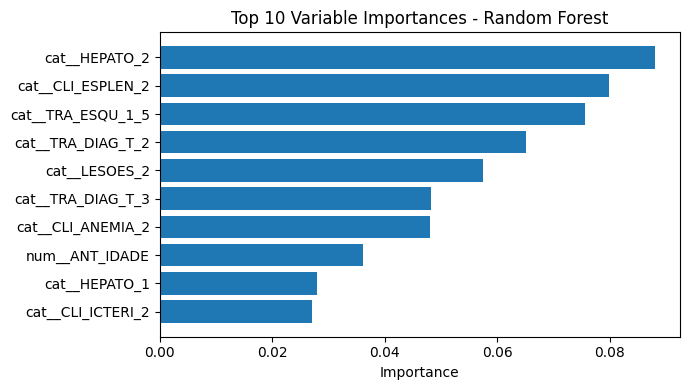

In [63]:
preproc = best_rf_model.named_steps['preprocess']
select = best_rf_model.named_steps['select']
names_after_preproc = preproc.get_feature_names_out()           
selected_feature_names = select.get_feature_names_out(names_after_preproc)

X_preproc = preproc.transform(X_train)
if hasattr(X_preproc, "toarray"):
    X_preproc = X_preproc.toarray()
X_preproc = X_preproc.astype(np.float64)
X_selected = select.transform(X_preproc)


# graph

plt.figure(figsize=(7, 4))
plt.barh(feat_imp_df['Feature'][::-1], feat_imp_df['Importance'][::-1])
plt.xlabel("Importance")
plt.title("Top 10 Variable Importances - Random Forest")
plt.tight_layout()
plt.show()

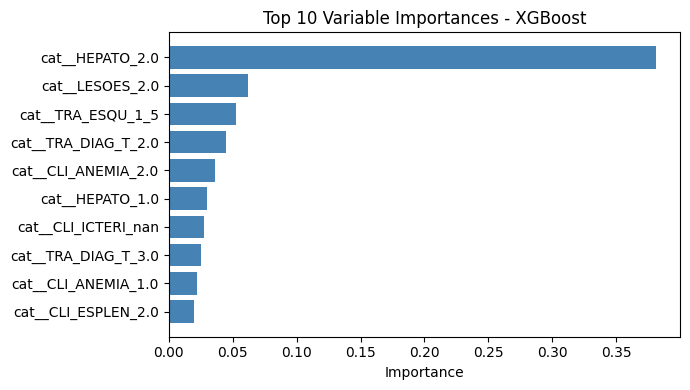

In [ ]:
# xgboost
preproc = best_xgb_model.named_steps['preprocess']
select = best_xgb_model.named_steps['select']
names_after_preproc = preproc.get_feature_names_out()
selected_feature_names = select.get_feature_names_out(names_after_preproc)
X_preproc = preproc.transform(X_train)
if hasattr(X_preproc, "toarray"):
    X_preproc = X_preproc.toarray()
X_preproc = X_preproc.astype(np.float64)

# Aplicar seleção de features
X_selected = select.transform(X_preproc)

importances = xgb_clf.feature_importances_

feat_imp_df = pd.DataFrame({
    'Feature': selected_feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False).head(10)

plt.figure(figsize=(7, 4))
plt.barh(feat_imp_df['Feature'][::-1], feat_imp_df['Importance'][::-1], color='steelblue')
plt.xlabel("Importance")
plt.title("Top 10 Variable Importances - XGBoost")
plt.tight_layout()
plt.show()

Using 200 background data samples could cause slower run times. Consider using shap.sample(data, K) or shap.kmeans(data, K) to summarize the background as K samples.
100%|██████████| 200/200 [28:46<00:00,  8.63s/it]


Shape shap_values: (200, 82)
Shape X_selected: (200, 82)


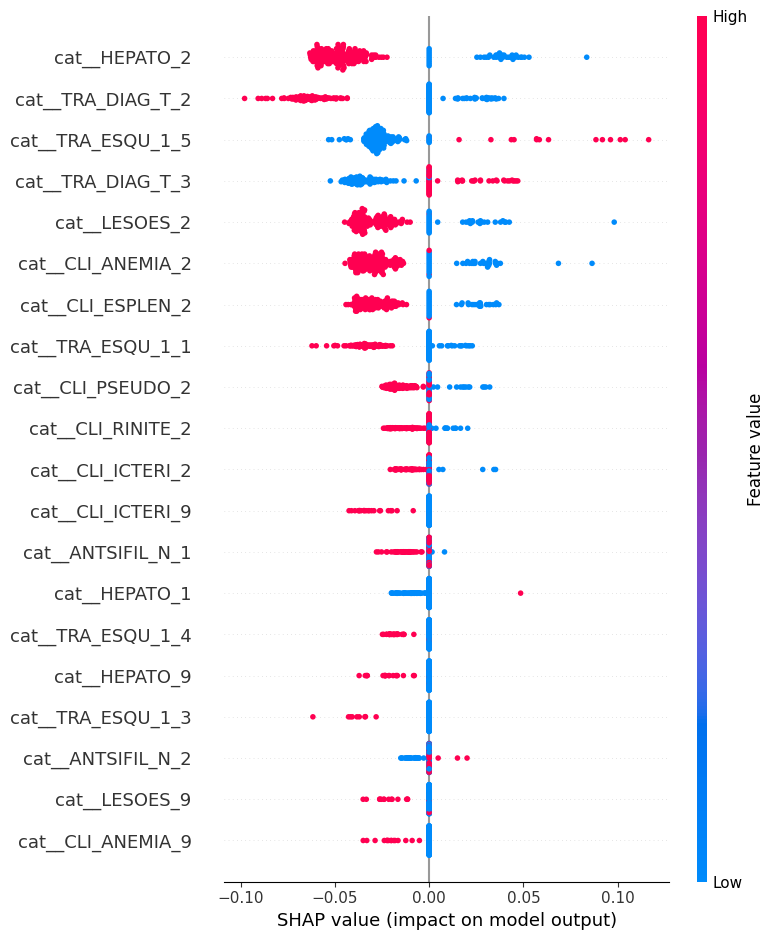

In [64]:
X_sample = shap.sample(X_selected, 200, random_state=42)

explainer = shap.KernelExplainer(lambda x: rf_clf.predict_proba(x)[:, 1], X_sample)

shap_values = explainer.shap_values(X_selected[:200])

print("Shape shap_values:", shap_values.shape)
print("Shape X_selected:", X_selected[:200].shape)

shap.summary_plot(
    shap_values,
    X_selected[:200],
    feature_names=selected_feature_names,
    show=True
)

Using 200 background data samples could cause slower run times. Consider using shap.sample(data, K) or shap.kmeans(data, K) to summarize the background as K samples.


100%|██████████| 200/200 [01:56<00:00,  1.71it/s]


Shape shap_values: (200, 91)
Shape X_selected: (200, 91)


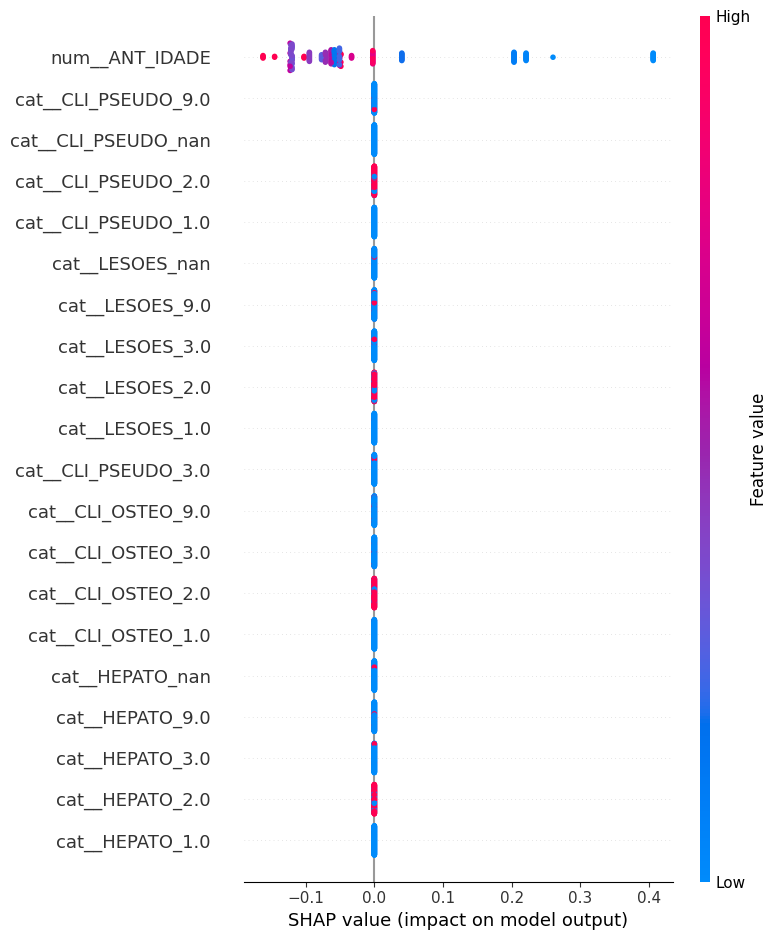

In [ ]:
#xgboost
X_sample = shap.sample(X_selected, 200, random_state=42)

explainer = shap.KernelExplainer(lambda x: xgb_clf.predict_proba(x)[:, 1], X_sample)

shap_values = explainer.shap_values(X_selected[:200])

print("Shape shap_values:", shap_values.shape)
print("Shape X_selected:", X_selected[:200].shape)

shap.summary_plot(
    shap_values,
    X_selected[:200],
    feature_names=selected_feature_names,
    show=True
)
